<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Liquidity_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

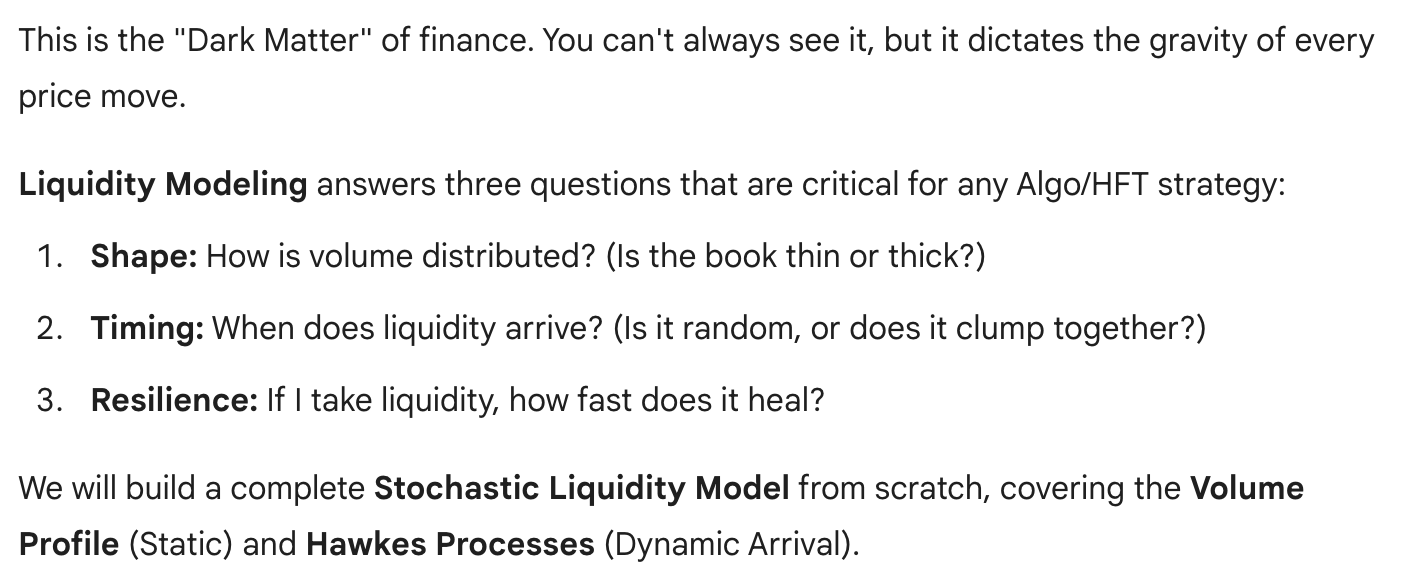

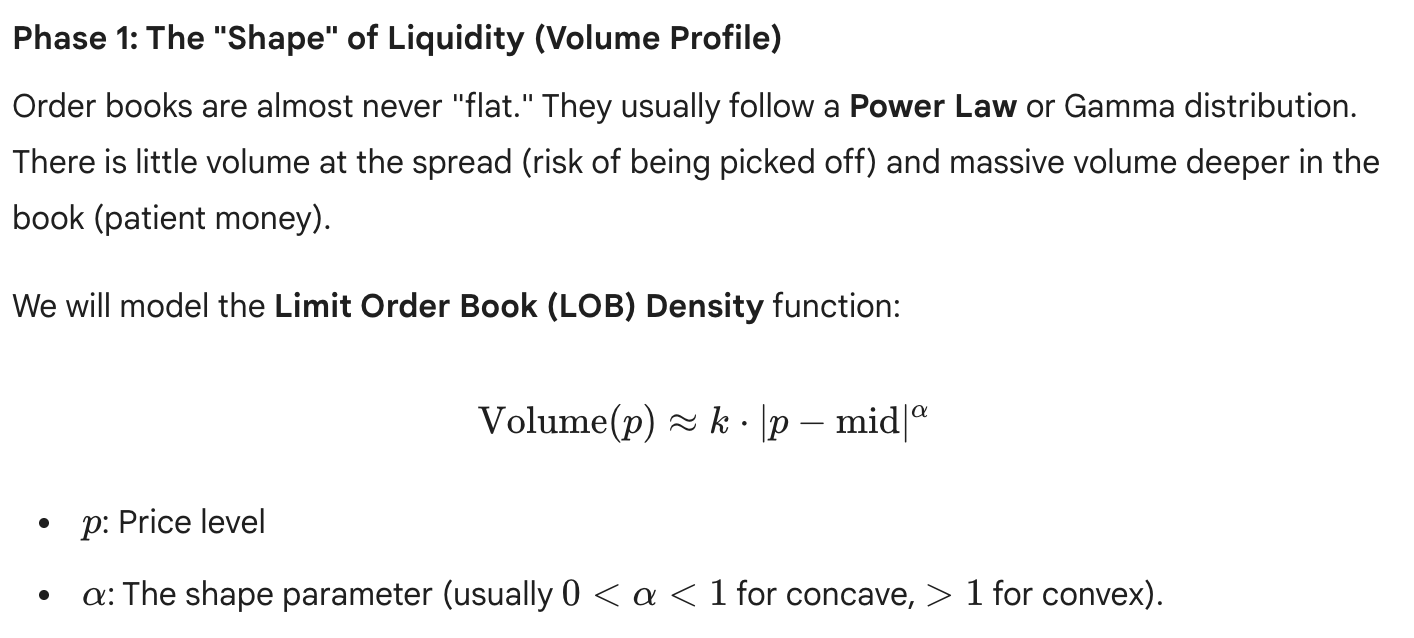

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gamma
import pandas as pd

In [2]:
# --- CONFIG ---
MID_PRICE = 100.0
DEPTH_LEVELS = 50
PRICE_STEP = 0.05

In [3]:
def generate_static_book(alpha=0.6, base_liquidity=100):
    """
    Generates a synthetic LOB shape using a Power Law.
    alpha < 1.0: Concave (Volume accumulates fast near spread)
    alpha > 1.0: Convex (Volume is thin near spread, huge deep down)
    """
    prices = []
    volumes = []

    # Generate Bids (Below Mid)
    for i in range(1, DEPTH_LEVELS + 1):
        p = MID_PRICE - (i * PRICE_STEP)
        # Model: Volume increases as we get further from mid
        distance = i * PRICE_STEP
        vol = base_liquidity + (base_liquidity * (distance ** alpha) * 10)
        # Add some noise
        vol *= np.random.normal(1.0, 0.1)
        prices.append(p)
        volumes.append(vol)

    bids = pd.DataFrame({'price': prices, 'vol': volumes, 'side': 'Bid'})

    # Generate Asks (Above Mid)
    prices = []
    volumes = []
    for i in range(1, DEPTH_LEVELS + 1):
        p = MID_PRICE + (i * PRICE_STEP)
        distance = i * PRICE_STEP
        vol = base_liquidity + (base_liquidity * (distance ** alpha) * 10)
        vol *= np.random.normal(1.0, 0.1)
        prices.append(p)
        volumes.append(vol)

    asks = pd.DataFrame({'price': prices, 'vol': volumes, 'side': 'Ask'})

    return bids, asks

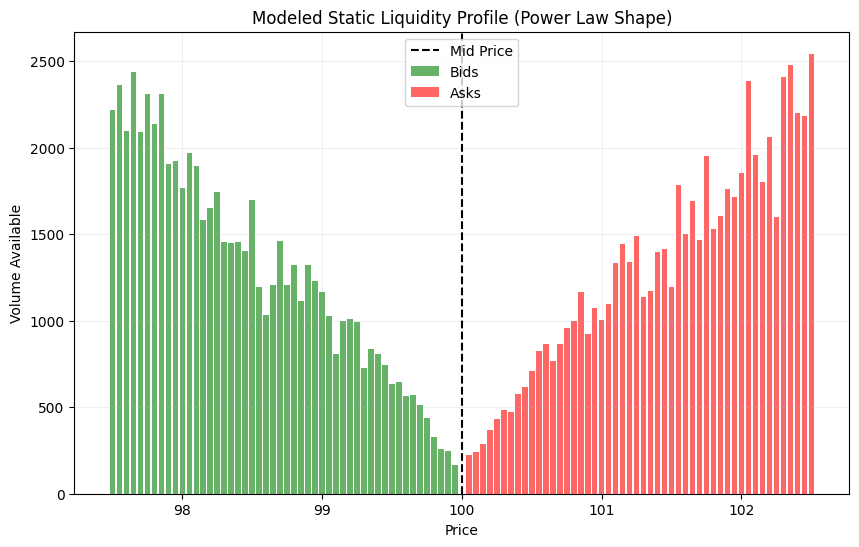

In [6]:
# Generate and Visualize
bids, asks = generate_static_book(alpha=0.8)

plt.figure(figsize=(10, 6))
# Plot Bids (Green, inverted x-axis conceptually for book view, but here standard)
plt.bar(bids['price'], bids['vol'], width=0.04, color='green', alpha=0.6, label='Bids')
plt.bar(asks['price'], asks['vol'], width=0.04, color='red', alpha=0.6, label='Asks')
plt.axvline(x=MID_PRICE, color='black', linestyle='--', label='Mid Price')
plt.title("Modeled Static Liquidity Profile (Power Law Shape)")
plt.xlabel("Price")
plt.ylabel("Volume Available")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

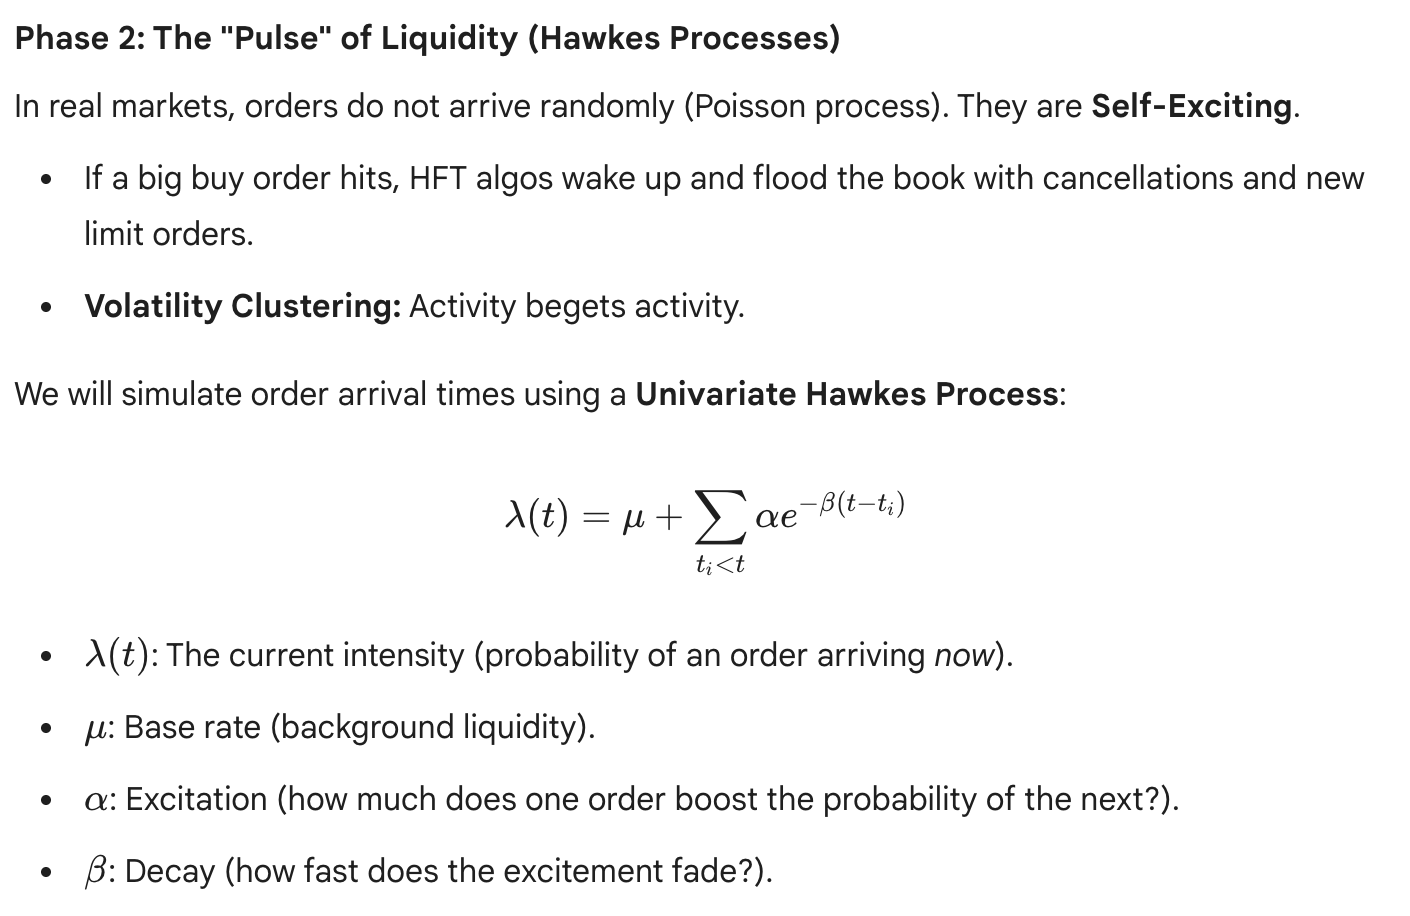

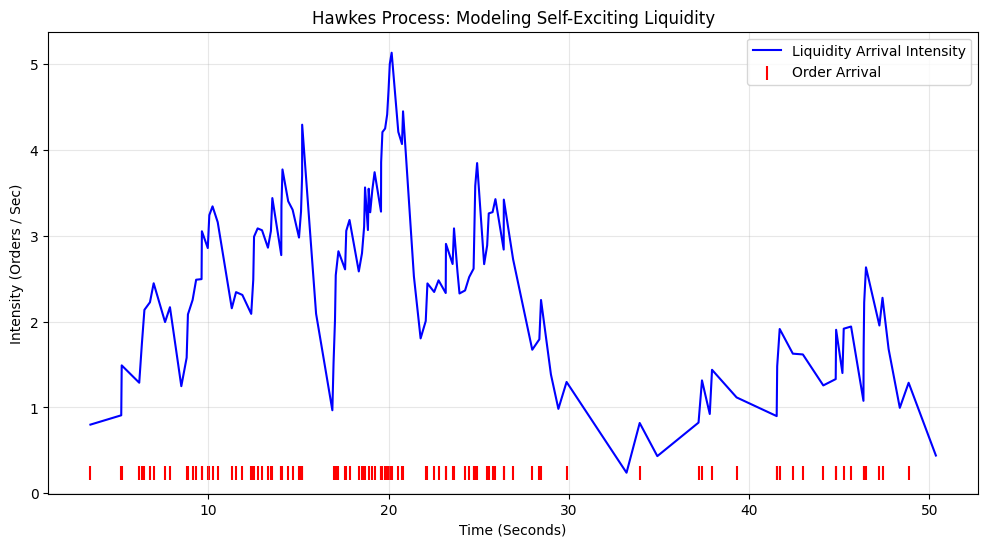

In [7]:
def simulate_hawkes_process(mu=0.5, alpha=0.8, beta=1.2, T=100):
    """
    Simulates order arrival times where history influences the future.
    """
    t = 0
    history = []
    intensity_path = []
    time_grid = []

    # Current intensity
    curr_lambda = mu

    while t < T:
        # 1. Upper bound for thinning algorithm (Ogata's method)
        # We need to sample the *next* event time
        upper_bound = curr_lambda + 1e-5

        # Propose time step from exponential dist based on upper bound
        step = np.random.exponential(1.0 / upper_bound)
        t += step

        # 2. Calculate actual intensity at proposed time t
        decay_sum = sum([np.exp(-beta * (t - ti)) for ti in history])
        actual_lambda = mu + alpha * decay_sum

        # 3. Acceptance / Rejection Step
        # This determines if an event actually happened
        if np.random.rand() < (actual_lambda / upper_bound):
            history.append(t)
            # Intensity jumps up by alpha immediately after event
            curr_lambda = actual_lambda + alpha
        else:
            curr_lambda = actual_lambda

        intensity_path.append(curr_lambda)
        time_grid.append(t)

    return history, time_grid, intensity_path

# Run Simulation
# alpha=0.8 means highly reactive market (1 order triggers 0.8 more orders on average)
arrival_times, t_grid, lambda_grid = simulate_hawkes_process(mu=0.2, alpha=0.6, beta=1.0, T=50)

# --- VISUALIZE THE PULSE ---
plt.figure(figsize=(12, 6))

# Plot Intensity Curve
plt.plot(t_grid, lambda_grid, color='blue', label='Liquidity Arrival Intensity')

# Plot Events (Rug Plot)
plt.scatter(arrival_times, [min(lambda_grid)]*len(arrival_times), color='red', marker='|', s=100, label='Order Arrival')

plt.title("Hawkes Process: Modeling Self-Exciting Liquidity")
plt.xlabel("Time (Seconds)")
plt.ylabel("Intensity (Orders / Sec)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

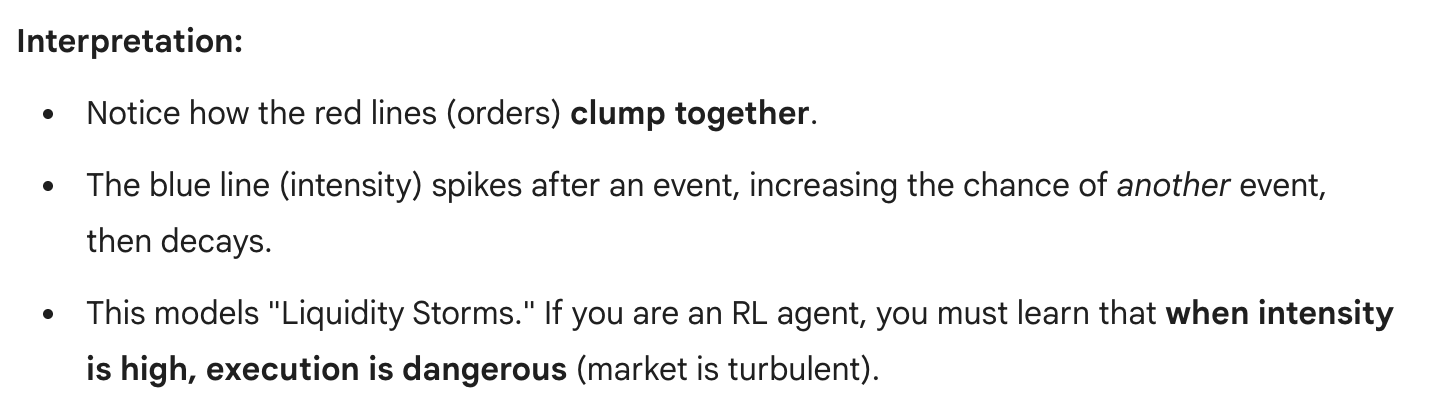

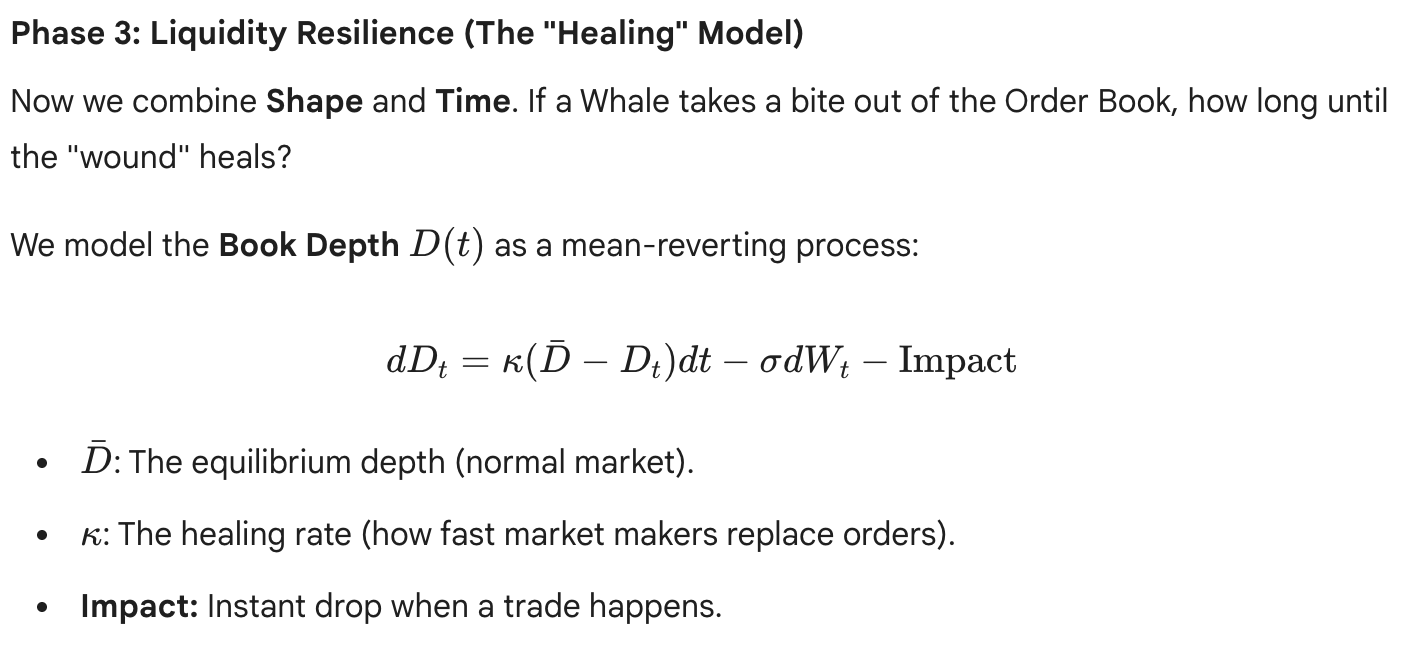

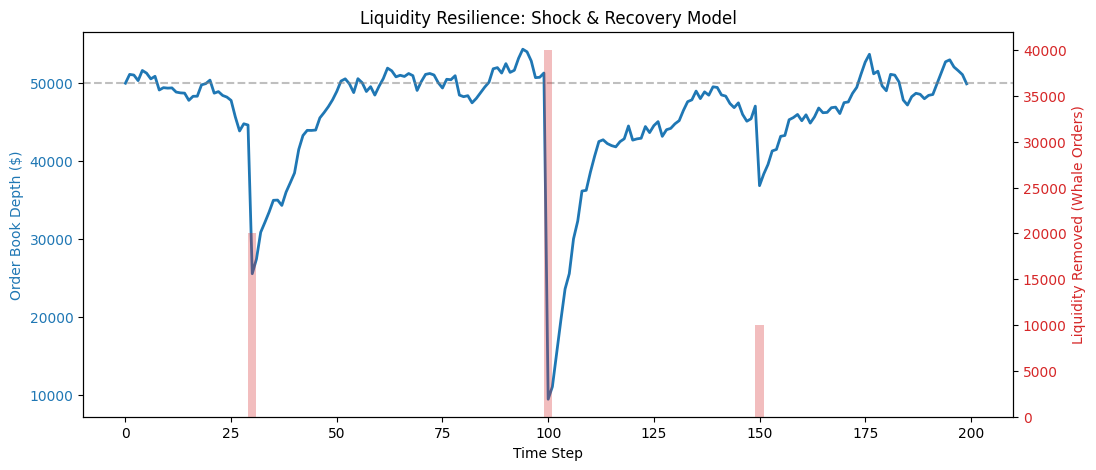

In [8]:
def simulate_liquidity_resilience(n_steps=200, equilibrium_depth=50000, healing_rate=0.1):
    depth = [equilibrium_depth]
    shocks = []

    # Define specific times where "Whales" eat liquidity
    whale_trades = {
        30: 20000,  # Small Whale
        100: 40000, # Big Whale (Crash)
        150: 10000  # Follow up
    }

    for t in range(1, n_steps):
        current = depth[-1]

        # 1. Natural Variation (Market Makers adjusting)
        noise = np.random.normal(0, 1000)

        # 2. Mean Reversion (Healing)
        # If current < equilibrium, this term is positive (refill)
        recovery = healing_rate * (equilibrium_depth - current)

        # 3. Apply Whale Impact if triggered
        shock = whale_trades.get(t, 0)
        shocks.append(shock)

        new_depth = current + recovery + noise - shock
        depth.append(max(0, new_depth)) # Depth can't be negative

    return depth, shocks

depth_curve, shock_hist = simulate_liquidity_resilience()

# --- PLOT RESILIENCE ---
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Order Book Depth ($)', color=color)
ax1.plot(depth_curve, color=color, linewidth=2, label="Available Liquidity")
ax1.axhline(y=50000, color='gray', linestyle='--', alpha=0.5, label="Equilibrium")
ax1.tick_params(axis='y', labelcolor=color)

# Plot Shocks on secondary axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Liquidity Removed (Whale Orders)', color=color)
ax2.bar(range(1, 200), shock_hist, color=color, alpha=0.3, width=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Liquidity Resilience: Shock & Recovery Model")
plt.show()

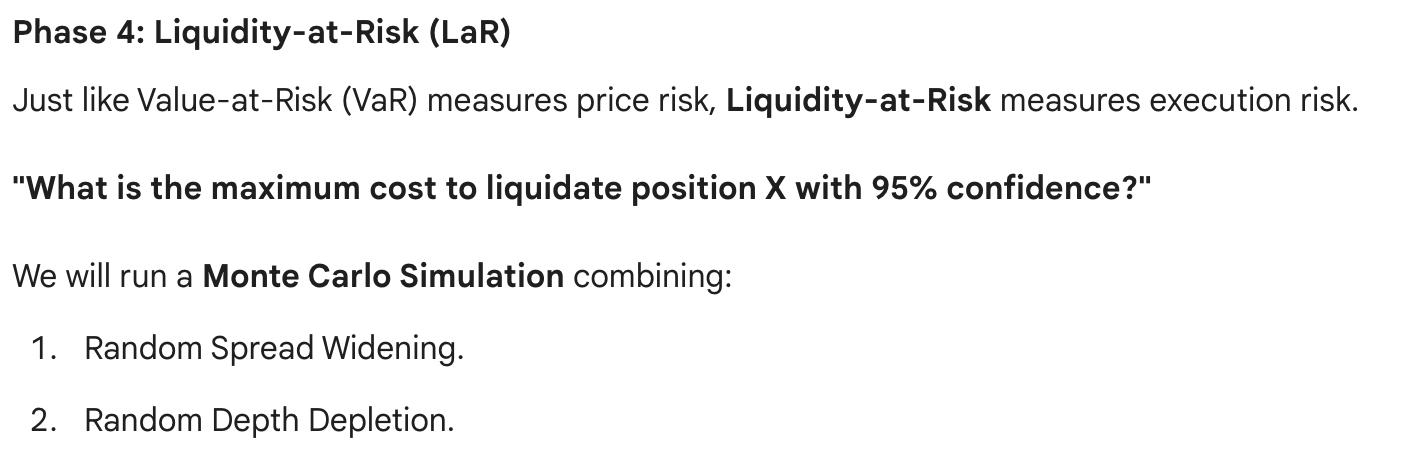

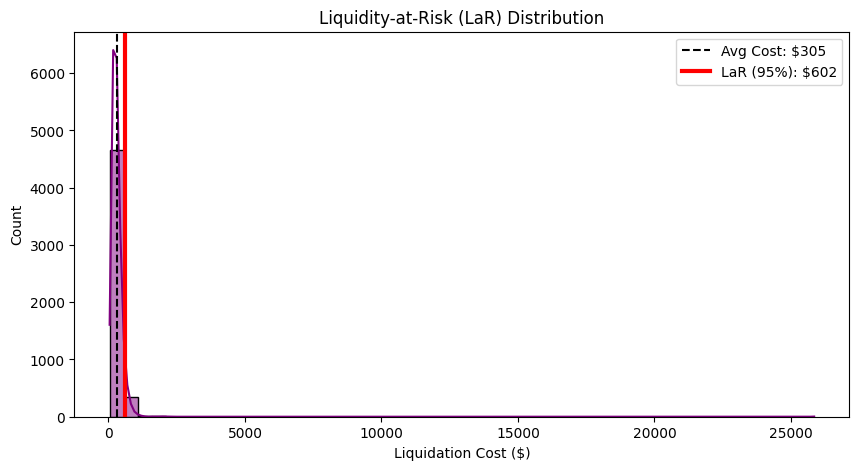

In [9]:
def calculate_liquidity_at_risk(position_size=10000, n_sims=5000):
    """
    Simulates 5000 scenarios of market conditions to find the worst-case cost.
    """
    # Parameters calibrated to a volatile asset
    avg_spread = 0.05
    vol_spread = 0.02

    avg_depth = 50000
    vol_depth = 15000

    costs = []

    for _ in range(n_sims):
        # 1. Simulate Market State
        # Spreads are Log-Normal (can't be negative, usually skew right)
        sim_spread = np.random.lognormal(mean=np.log(avg_spread), sigma=0.5)

        # Depth is Normal (clipped at 1000)
        sim_depth = max(1000, np.random.normal(avg_depth, vol_depth))

        # 2. Calculate Execution Cost
        # Simple model: Cost = (Half Spread) + (Market Impact)
        # Impact increases if Position > Sim_Depth
        impact_factor = (position_size / sim_depth) ** 2 # Convex impact cost

        unit_cost = (sim_spread / 2) * (1 + impact_factor)
        total_cost = unit_cost * position_size
        costs.append(total_cost)

    # 3. Calculate LaR (95th Percentile)
    LaR_95 = np.percentile(costs, 95)
    mean_cost = np.mean(costs)

    return costs, mean_cost, LaR_95

costs, avg_c, lar = calculate_liquidity_at_risk()

plt.figure(figsize=(10, 5))
sns.histplot(costs, kde=True, color='purple', bins=50)
plt.axvline(x=avg_c, color='black', linestyle='--', label=f'Avg Cost: ${avg_c:.0f}')
plt.axvline(x=lar, color='red', linewidth=3, label=f'LaR (95%): ${lar:.0f}')
plt.title("Liquidity-at-Risk (LaR) Distribution")
plt.xlabel("Liquidation Cost ($)")
plt.legend()
plt.show()

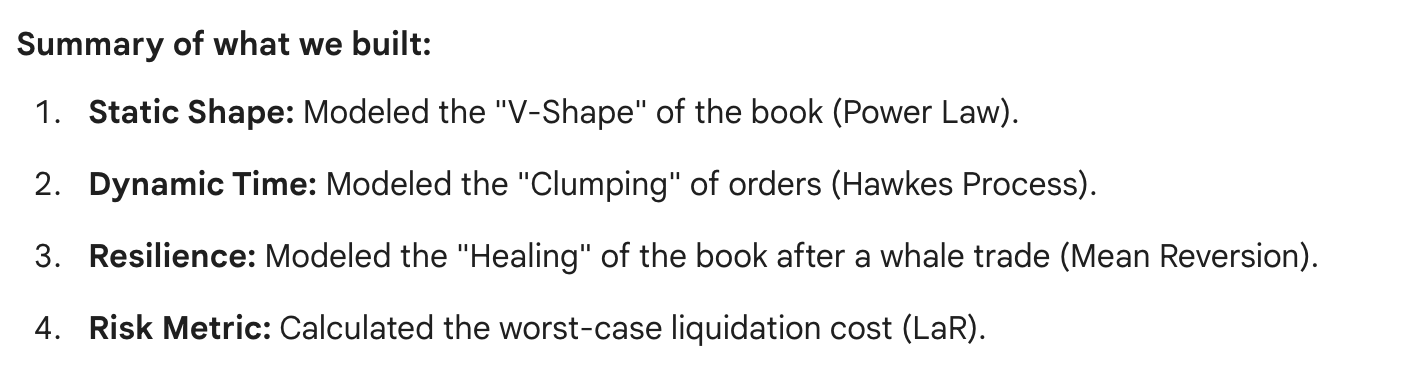